In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel(r"C:\Users\Hp Envy\Desktop\Online Retail.xlsx")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst rows:\n{df.head()}")

Shape: (541909, 8)

Column types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

First rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country

## Task 1

### 1.1

In [2]:
print(f"Number of rows and columns: {df.shape}")

usage = df.memory_usage(deep=True)
total_usage = usage.sum() / (1024**2)
print(f"\nMemory usage: {total_usage:.2f} MB")

missing_values = df.isnull().sum()
percentages_of_missing_values  = (df.isnull().sum() / len(df))*100
print(f"\nMissing values:\n {missing_values}")
print(f"\nPecenatges:\n {percentages_of_missing_values}")

print(f"\nUnique values:\n{df.nunique()}")

print(f"\nMax:\n{df[["Quantity", "UnitPrice"]].max()}")
print(f"\nMin:\n{df[["Quantity", "UnitPrice"]].min()}")
print(f"\nMean:\n{df[["Quantity", "UnitPrice"]].mean()}")
print(f"\nMedian:\n{df[["Quantity", "UnitPrice"]].median()}")
print(f"\nStd:\n{df[["Quantity", "UnitPrice"]].std()}")

Number of rows and columns: (541909, 8)

Memory usage: 126.18 MB

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Pecenatges:
 InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

Unique values:
InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

Max:
Quantity     80995.0
UnitPrice    38970.0
dtype: float64

Min:
Quantity    -80995.00
UnitPrice   -11062.06
dtype: float64

Mean:
Quantity     9.552250
UnitPrice    4.611114
dtype: float64

Median:
Quantity     3.00
UnitPrice    2.08
dtype: float64

Std:
Quantity     218.081158
UnitPrice     96.7

In [3]:
# CustomerID olan və olmayan sətirlərin müqayisəsi
df['Has_CustomerID'] = df['CustomerID'].notnull()

comparison = df.groupby('Has_CustomerID').agg({
    'Quantity': 'mean',
    'UnitPrice': 'mean',
    'Country': lambda x: x.mode()[0] # Ən çox təkrar olunan ölkə
}).reset_index()

print("CustomerID-si olan vs olmayanların fərqi:")
print(comparison)

CustomerID-si olan vs olmayanların fərqi:
   Has_CustomerID   Quantity  UnitPrice         Country
0           False   1.995573   8.076577  United Kingdom
1            True  12.061303   3.460471  United Kingdom


In [4]:
# 1. Addım: Description sütunundakı boşluqların təmizlənməsi
# Səbəb: UnitPrice 0.0 olduğu üçün bu sətirlər real satışı təmsil etmir (MNAR).
initial_count = len(df)
df = df.dropna(subset=['Description'])
dropped_description = initial_count - len(df)

# 2. Addım: CustomerID sütunundakı boşluqların doldurulması
# Səbəb: Bunlar real satışlardır (UnitPrice > 0), lakin müştəri anonimdir (MAR).
# Onları silmək gəlir analizini korlayar, ona görə 'Guest' olaraq qeyd edirik.
df['CustomerID'] = df['CustomerID'].fillna('Guest')

# 3. Addım: Nəticənin yoxlanılması
print("--- Təmizləmə Hesabatı ---")
print(f"Silinən yararsız sətir sayı (Description NULL): {dropped_description}")
print(f"Doldurulan anonim müştəri sayı (CustomerID NULL): { (df['CustomerID'] == 'Guest').sum() }")
print("\nQalan Missing Value sayları:")
print(df.isnull().sum())

--- Təmizləmə Hesabatı ---
Silinən yararsız sətir sayı (Description NULL): 1454
Doldurulan anonim müştəri sayı (CustomerID NULL): 133626

Qalan Missing Value sayları:
InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
Has_CustomerID    0
dtype: int64


In [5]:
# InvoiceNo string tipinə çevrilmiş olduğundan əmin oluruq
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# 'C' ilə başlayanları tapırıq
cancellations = df[df['InvoiceNo'].str.startswith('C')]

print(f"Ləğv edilmiş əməliyyatların sayı: {len(cancellations)}")
print(f"Ləğv edilmiş sətirlərdə mənfi miqdar varmı? { (cancellations['Quantity'] < 0).all() }")

Ləğv edilmiş əməliyyatların sayı: 9288
Ləğv edilmiş sətirlərdə mənfi miqdar varmı? True


## Task 2

Mənfi və ya sıfır miqdar (non-C): 9762


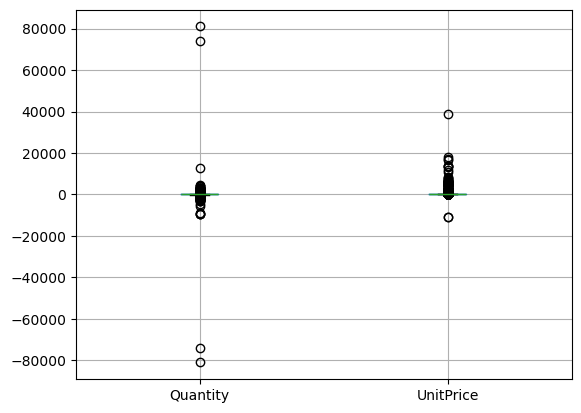

İlkin sətir sayı: 540455
Təmizləmədən sonrakı sətir sayı: 529027


In [6]:
invalid_qty = df[(df['Quantity'] <= 0)]
print(f"Mənfi və ya sıfır miqdar (non-C): {len(invalid_qty)}")
import matplotlib.pyplot as plt
df[['Quantity', 'UnitPrice']].boxplot()
plt.show()
# 1. Miqdar və Qiymət təmizlənməsi
df_cleaned = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# 2. Outlier-lərin idarə olunması (Məsələn, 99% persentildən yuxarı olanları silmək)
q_limit = df_cleaned['Quantity'].quantile(0.999)
p_limit = df_cleaned['UnitPrice'].quantile(0.999)

df_final = df_cleaned[(df_cleaned['Quantity'] < q_limit) & (df_cleaned['UnitPrice'] < p_limit)]

print(f"İlkin sətir sayı: {len(df)}")
print(f"Təmizləmədən sonrakı sətir sayı: {len(df_final)}")

In [7]:
# Başlanğıc ölçünü yadda saxlayırıq
shape_before = df.shape

# 1. Qayda: Yalnız müsbət Miqdar (Quantity > 0)
# Bu həm ləğvləri (C), həm də digər mənfi inventar qeydlərini təmizləyir.
df_valid = df[df['Quantity'] > 0].copy()

# 2. Qayda: Yalnız müsbət Qiymət (UnitPrice > 0)
# Sıfır və ya mənfi qiymətli sətirlər (hədiyyələr, xətalar) kənarlaşdırılır.
df_valid = df_valid[df_valid['UnitPrice'] > 0]

# Final ölçünü yadda saxlayırıq
shape_after = df_valid.shape

print(f"--- Dataset Ölçü Müqayisəsi ---")
print(f"Təmizləmədən əvvəl: {shape_before}")
print(f"Təmizləmədən sonra: {shape_after}")
print(f"Silinən cəmi sətir: {shape_before[0] - shape_after[0]}")

print("\n--- Validasiya Yoxlaması ---")
print(f"Mənfi və ya sıfır miqdar qalıbmı?: {(df_valid['Quantity'] <= 0).any()}")
print(f"Mənfi və ya sıfır qiymət qalıbmı?: {(df_valid['UnitPrice'] <= 0).any()}")

# Əlavə olaraq sütun tiplərini və boşluqları son dəfə yoxlayaq
print("\nQalan boş dəyərlər:")
print(df_valid.isnull().sum())

--- Dataset Ölçü Müqayisəsi ---
Təmizləmədən əvvəl: (540455, 9)
Təmizləmədən sonra: (530104, 9)
Silinən cəmi sətir: 10351

--- Validasiya Yoxlaması ---
Mənfi və ya sıfır miqdar qalıbmı?: False
Mənfi və ya sıfır qiymət qalıbmı?: False

Qalan boş dəyərlər:
InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
Has_CustomerID    0
dtype: int64


## Task 3

In [8]:
# 1. Unikal ölkələrin sayı
unique_countries_count = df_valid['Country'].nunique()
print(f"İlkin unikal ölkə sayı: {unique_countries_count}")

# 2. Top 5 ölkənin ümumi tranzaksiyalardakı faizi
country_counts = df_valid['Country'].value_counts()
top_5_percentage = (country_counts.head(5).sum() / len(df_valid)) * 100
print(f"Top 5 ölkənin payı: %{top_5_percentage:.2f}")

# 3. 50-dən az tranzaksiyası olan ölkələrin sayı
rare_countries = country_counts[country_counts < 50]
print(f"50-dən az tranzaksiyası olan ölkə sayı: {len(rare_countries)}")

# 4. Nadir ölkələrin "Other" kateqoriyasında qruplaşdırılması
# Rare countries siyahısındakı ölkələri "Other" ilə əvəzləyirik
df_valid['Country_Cleaned'] = df_valid['Country'].apply(lambda x: 'Other' if x in rare_countries else x)

# 5. Qruplaşdırmadan əvvəl və sonrakı kateqoriya sayının müqayisəsi
print(f"\nTransformasiyadan əvvəl kateqoriya sayı: {df_valid['Country'].nunique()}")
print(f"Transformasiyadan sonra kateqoriya sayı: {df_valid['Country_Cleaned'].nunique()}")

İlkin unikal ölkə sayı: 38
Top 5 ölkənin payı: %96.76
50-dən az tranzaksiyası olan ölkə sayı: 6

Transformasiyadan əvvəl kateqoriya sayı: 38
Transformasiyadan sonra kateqoriya sayı: 33


In [10]:
unique_stock_codes = df_valid['StockCode'].nunique()
print(f"Unikal StockCode sayı: {unique_stock_codes}")
# Rəqəmlə başlamayan və ya çox qısa/uzun olan şübhəli kodları tapırıq
import re

def is_unusual(code):
    code = str(code)
    # Əgər kod tamamilə hərflərdən ibarətdirsə və ya xüsusi adıdırsa
    if re.match(r'^[a-zA-Z]+$', code):
        return True
    return False

unusual_codes = df_valid[df_valid['StockCode'].apply(is_unusual)]['StockCode'].unique()
print(f"Şübhəli (qeyri-məhsul) kodlar: {unusual_codes}")

# Silmək istədiyimiz xüsusi kodların siyahısı
non_product_codes = ['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'BANK CHARGES', 'C2']

# Dataseti təmizləyirik
df_product_only = df_valid[~df_valid['StockCode'].isin(non_product_codes)].copy()

# Həmçinin hərfdən ibarət olan hər şeyi süzgəcdən keçirə bilərik
df_product_only = df_product_only[df_product_only['StockCode'].str.contains(r'\d', na=False)]

print(f"Təmizləmədən əvvəl sətir sayı: {len(df_valid)}")
print(f"Təmizləmədən sonra (yalnız məhsullar): {len(df_product_only)}")

Unikal StockCode sayı: 3922
Şübhəli (qeyri-məhsul) kodlar: ['POST' 'DOT' 'M' 'AMAZONFEE' 'm' 'DCGSSBOY' 'DCGSSGIRL' 'S' 'PADS' 'B']
Təmizləmədən əvvəl sətir sayı: 530104
Təmizləmədən sonra (yalnız məhsullar): 50669


In [11]:
# Sütunu böyük hərflərə çeviririk ki, axtarış dəqiq olsun
df_product_only['Description'] = df_product_only['Description'].str.upper()

# 1. 'Is_Bulk' xüsusiyyəti (Dəst/Paket)
bulk_keywords = ['SET', 'PACK', 'BOX', 'CASE', 'BUNDLE']
df_product_only['Is_Bulk'] = df_product_only['Description'].apply(
    lambda x: 1 if any(word in str(x) for word in bulk_keywords) else 0
)

# 2. 'Is_Vintage' xüsusiyyəti
df_product_only['Is_Vintage'] = df_product_only['Description'].apply(
    lambda x: 1 if 'VINTAGE' in str(x) else 0
)

# 3. Təsvirin uzunluğu (Word Count)
df_product_only['Desc_Word_Count'] = df_product_only['Description'].apply(lambda x: len(str(x).split()))

# Is_Bulk üzrə analiz
bulk_analysis = df_product_only.groupby('Is_Bulk').agg({
    'UnitPrice': 'mean',
    'Quantity': 'mean'
}).reset_index()

print("Dəst (Bulk) vs Tək-tək satış müqayisəsi:")
print(bulk_analysis)

# Is_Vintage üzrə analiz
vintage_analysis = df_product_only.groupby('Is_Vintage')[['UnitPrice']].mean()
print("\nVintage vs Müasir dizayn qiymət müqayisəsi:")
print(vintage_analysis)

Dəst (Bulk) vs Tək-tək satış müqayisəsi:
   Is_Bulk  UnitPrice  Quantity
0        0   3.011072  9.292748
1        1   4.160832  6.330127

Vintage vs Müasir dizayn qiymət müqayisəsi:
            UnitPrice
Is_Vintage           
0            3.093013
1           10.795279


## Task 4

In [12]:
# Hər sətir üçün gəliri (Revenue) hesablayaq
df_product_only['revenue'] = df_product_only['Quantity'] * df_product_only['UnitPrice']

# Müştəri bazlı qruplaşdırma
customer_df = df_product_only.groupby('CustomerID').agg({
    'revenue': 'sum',                        # Ümumi xərcləmə (Total Revenue)
    'InvoiceNo': 'nunique',                  # Cəmi sifariş sayı (Order Count)
    'StockCode': 'nunique',                  # Alınan fərqli məhsul sayı
    'InvoiceDate': ['min', 'max']            # İlk və son alış-veriş tarixləri
})

# Sütun adlarını düzəldirik
customer_df.columns = [
    'total_revenue', 
    'order_count', 
    'distinct_products', 
    'first_purchase', 
    'last_purchase'
]
customer_df = customer_df.reset_index()

# 'Guest' müştəriləri analizdən kənar tutmaq və ya ayrıca idarə etmək üçün:
# customer_df = customer_df[customer_df['CustomerID'] != 'Guest']

In [15]:
# Sütun adlarını yoxla (əmin olmaq üçün)
print("Mövcud sütunlar:", customer_df.columns)

# Əgər is_high_value yoxdursa, onu yaradırıq
if 'total_revenue' in customer_df.columns:
    threshold = customer_df['total_revenue'].quantile(0.90)
    customer_df['is_high_value'] = (customer_df['total_revenue'] >= threshold).astype(int)
    print(f"Sütun uğurla yaradıldı. Limit: {threshold:.2f}")
else:
    print("Xəta: 'total_revenue' sütunu tapılmadı! Əvvəlcə aqreqasiya addımını icra etməlisən.")

# İndi paylanmanı hesablaya bilərsən
distribution = customer_df['is_high_value'].value_counts(normalize=True) * 100
print(f"\nSinfi paylanması:\n{distribution}")

# Əgər hər kəsə "0" (Regular) desəydik:
baseline_accuracy = (customer_df['is_high_value'] == 0).mean() * 100
print(f"Baseline Accuracy (Hər kəsə 'Regular' desək): {baseline_accuracy:.2f}%")

Mövcud sütunlar: Index(['CustomerID', 'total_revenue', 'order_count', 'distinct_products',
       'first_purchase', 'last_purchase'],
      dtype='object')
Sütun uğurla yaradıldı. Limit: 371.97

Sinfi paylanması:
is_high_value
0    89.978613
1    10.021387
Name: proportion, dtype: float64
Baseline Accuracy (Hər kəsə 'Regular' desək): 89.98%


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Xüsusiyyətlər: Tarixləri çıxarırıq, çünki model birbaşa datetime formatını qəbul etmir
X = customer_df[['total_revenue', 'order_count', 'distinct_products']]
y = customer_df['is_high_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ölçək fərqlərini aradan qaldırmaq üçün Scaling edirik (Logistic Regression üçün vacibdir)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# 1. Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled_over, y_resampled_over = ros.fit_resample(X_train_scaled, y_train)

# 2. Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled_under, y_resampled_under = rus.fit_resample(X_train_scaled, y_train)

print(f"Orijinal Train paylanması: {y_train.value_counts().to_dict()}")
print(f"Oversampling sonrası: {y_resampled_over.value_counts().to_dict()}")
print(f"Undersampling sonrası: {y_resampled_under.value_counts().to_dict()}")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

models = {
    "Original": (X_train_scaled, y_train),
    "Oversampled": (X_resampled_over, y_resampled_over),
    "Undersampled": (X_resampled_under, y_resampled_under)
}

for name, (X_tr, y_tr) in models.items():
    model = LogisticRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n--- Model: {name} ---")
    # Bizə əsasən High-Value (class 1) lazımdır
    print(classification_report(y_test, y_pred))

Orijinal Train paylanması: {0: 2356, 1: 262}
Oversampling sonrası: {0: 2356, 1: 2356}
Undersampling sonrası: {0: 262, 1: 262}

--- Model: Original ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       589
           1       1.00      0.83      0.91        66

    accuracy                           0.98       655
   macro avg       0.99      0.92      0.95       655
weighted avg       0.98      0.98      0.98       655


--- Model: Oversampled ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       589
           1       0.87      1.00      0.93        66

    accuracy                           0.98       655
   macro avg       0.93      0.99      0.96       655
weighted avg       0.99      0.98      0.99       655


--- Model: Undersampled ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       589
           1       0.79      

## Task 5

In [17]:
# 1. Hədəf (Target): Müştəri Dekabr 2011-də alış edibmi?
december_customers = df_product_only[df_product_only['InvoiceDate'] >= '2011-12-01']['CustomerID'].unique()
customer_df['bought_in_dec'] = customer_df['CustomerID'].apply(lambda x: 1 if x in december_customers else 0)

# 2. Xüsusiyyətlər (Features): BÜTÜN ili əhatə edən aqreqatlar (SƏHV BURADADIR)
# Biz artıq 4.1-də customer_df-i bütün tarixlər üzrə hesablamışdıq.
X_wrong = customer_df[['total_revenue', 'order_count', 'distinct_products']]
y_wrong = customer_df['bought_in_dec']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Random split (Zaman sırasını nəzərə almadan)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_wrong, y_wrong, test_size=0.2, random_state=42)

# Modelin təlimi
leaky_model = RandomForestClassifier(random_state=42)
leaky_model.fit(X_train_w, y_train_w)

# Nəticələr
y_pred_w = leaky_model.predict(X_test_w)
print("--- Temporal Leakage olan modelin nəticələri ---")
print(classification_report(y_test_w, y_pred_w))
print(f"ROC AUC Score: {roc_auc_score(y_test_w, leaky_model.predict_proba(X_test_w)[:, 1]):.4f}")

--- Temporal Leakage olan modelin nəticələri ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       580
           1       0.38      0.16      0.22        75

    accuracy                           0.87       655
   macro avg       0.64      0.56      0.58       655
weighted avg       0.84      0.87      0.85       655

ROC AUC Score: 0.7700


In [18]:
# Proqnoz hədəfimiz: 2011-12-01 və sonrası
# Xüsusiyyətlərimizin bitmə tarixi:
features_end_date = df_product_only['InvoiceDate'].max()

print(f"Hədəf periodun başlanğıcı: 2011-12-01")
print(f"Xüsusiyyətlərin hesablandığı son tarix: {features_end_date}")

if features_end_date >= pd.Timestamp('2011-12-01'):
    print("\n[!] TƏHLÜKƏ: Zaman Sızması Aşkar Edildi!")
    print("Xüsusiyyətlər hədəf periodun daxilindəki datadan hesablanıb.")

# Korrelyasiya matrisini hesabla
correlations = customer_df[['total_revenue', 'order_count', 'distinct_products', 'bought_in_dec']].corr()

print("Hədəf (bought_in_dec) ilə korrelyasiyalar:")
print(correlations['bought_in_dec'].sort_values(ascending=False))

Hədəf periodun başlanğıcı: 2011-12-01
Xüsusiyyətlərin hesablandığı son tarix: 2011-12-09 12:20:00

[!] TƏHLÜKƏ: Zaman Sızması Aşkar Edildi!
Xüsusiyyətlər hədəf periodun daxilindəki datadan hesablanıb.
Hədəf (bought_in_dec) ilə korrelyasiyalar:
bought_in_dec        1.000000
distinct_products    0.195720
order_count          0.140519
total_revenue        0.099386
Name: bought_in_dec, dtype: float64


In [19]:
import pandas as pd

# Zaman divarını təyin edirik
observation_end = pd.Timestamp("2011-09-30")
prediction_start = pd.Timestamp("2011-10-01")

# 1. Müşahidə Pəncərəsi: Xüsusiyyətləri (Features) buradan hesablayırıq
df_obs = df_product_only[df_product_only["InvoiceDate"] <= observation_end]

# 2. Proqnoz Pəncərəsi: Hədəf dəyişənini (Target) buradan müəyyən edirik
df_pred = df_product_only[df_product_only["InvoiceDate"] >= prediction_start]

# Features (Sentyabrın sonuna qədər olan davranış)
X_correct = df_obs.groupby("CustomerID").agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'InvoiceNo': 'nunique'
}).rename(columns={'Quantity': 'total_qty', 'UnitPrice': 'avg_price', 'InvoiceNo': 'order_count'})

# Target (Oktyabr-Dekabr aralığında alış edibmi?)
future_buyers = df_pred['CustomerID'].unique()
X_correct['will_buy_future'] = X_correct.index.map(lambda x: 1 if x in future_buyers else 0)

# Final dataset
y_correct = X_correct['will_buy_future']
X_correct = X_correct.drop(columns=['will_buy_future'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_correct, y_correct, test_size=0.2, random_state=42)

correct_model = RandomForestClassifier(random_state=42)
correct_model.fit(X_train_c, y_train_c)

y_pred_c = correct_model.predict(X_test_c)
print("--- Düzgün Temporal Split Model Nəticələri ---")
print(classification_report(y_test_c, y_pred_c))

--- Düzgün Temporal Split Model Nəticələri ---
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       325
           1       0.54      0.48      0.51       218

    accuracy                           0.63       543
   macro avg       0.61      0.60      0.60       543
weighted avg       0.62      0.63      0.62       543

